# Lesson 06 — Interactions

<h2 dir="rtl">פרק 1 — פתיחה ורענון משיעור 05</h2>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

<h2 dir="rtl">פרק 2 — מה זה אינטראקציה? המבנה והאינטואיציה</h2>

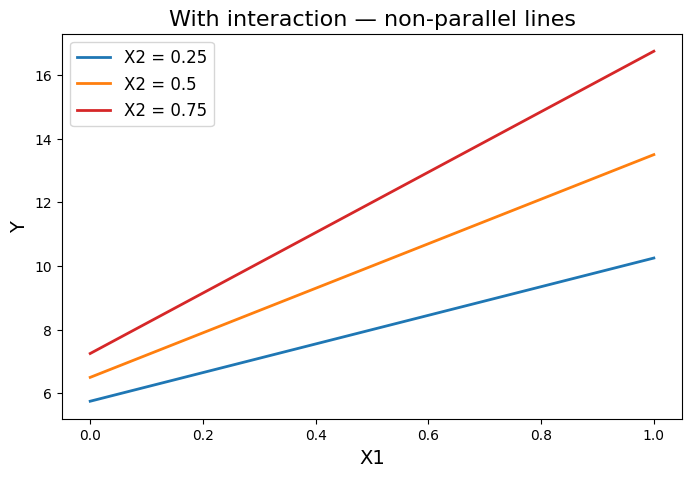

In [2]:
x_vals = np.linspace(0, 1, 50)
fig, ax = plt.subplots(figsize=(8, 5))
for x2_level, color in [(0.25, 'tab:blue'), (0.50, 'tab:orange'), (0.75, 'tab:red')]:
    y_vals = 5 + 2*x_vals + 3*x2_level + 10*x_vals*x2_level
    ax.plot(x_vals, y_vals, label=f'X2 = {x2_level}', linewidth=2, color=color)
ax.set_xlabel('X1', fontsize=14)
ax.set_ylabel('Y', fontsize=14)
ax.set_title('With interaction — non-parallel lines', fontsize=16)
ax.legend(fontsize=12)
plt.show()

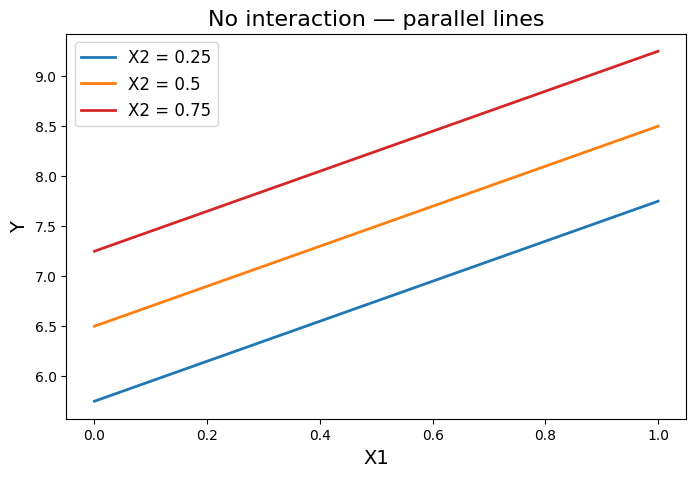

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
for x2_level, color in [(0.25, 'tab:blue'), (0.50, 'tab:orange'), (0.75, 'tab:red')]:
    y_vals = 5 + 2*x_vals + 3*x2_level  # no x1*x2 term
    ax.plot(x_vals, y_vals, label=f'X2 = {x2_level}', linewidth=2, color=color)
ax.set_xlabel('X1', fontsize=14)
ax.set_ylabel('Y', fontsize=14)
ax.set_title('No interaction — parallel lines', fontsize=16)
ax.legend(fontsize=12)
plt.show()

<h2 dir="rtl">פרק 3 — דאטה: training_hours × machine_type</h2>

In [4]:
rng = np.random.default_rng(42)
n = 80
training = rng.uniform(0, 40, size=n)
machine_type = rng.choice(['Light', 'Heavy'], size=n)
is_heavy = (machine_type == 'Heavy').astype(int)

y_true = 8 - 0.3*training + 4*is_heavy - 0.5*(training*is_heavy)
incidents = y_true + rng.normal(0, 1.5, size=n)

df = pd.DataFrame({
    'training_hours': training,
    'machine_type': machine_type,
    'incidents': incidents,
})
df.head()

,training_hours,machine_type,incidents
0,30.958242,Heavy,-10.363925
1,17.555138,Heavy,-2.403144
2,34.343917,Light,-3.838421
3,27.894721,Light,-0.099503
4,3.767094,Light,7.199867


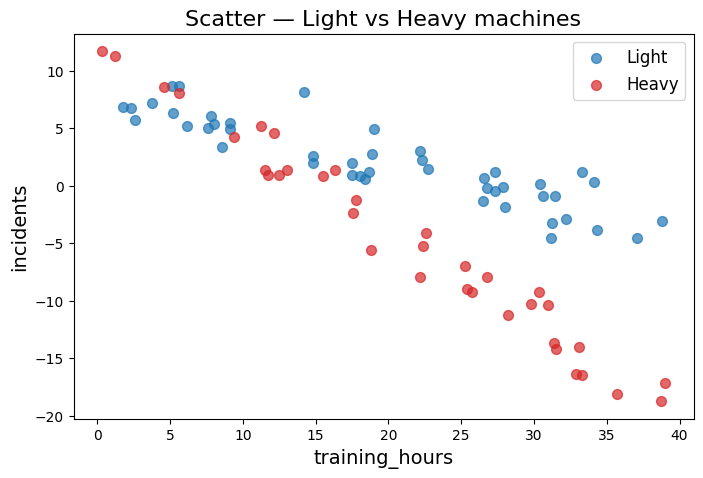

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
for mt, color in [('Light', 'tab:blue'), ('Heavy', 'tab:red')]:
    mask = df['machine_type'] == mt
    ax.scatter(df.loc[mask, 'training_hours'], df.loc[mask, 'incidents'],
               label=mt, alpha=0.7, s=50, color=color)
ax.set_xlabel('training_hours', fontsize=14)
ax.set_ylabel('incidents', fontsize=14)
ax.set_title('Scatter — Light vs Heavy machines', fontsize=16)
ax.legend(fontsize=12)
plt.show()

<h2 dir="rtl">פרק 4 — מודל אדיטיבי (ולמה לא מספיק)</h2>

                            OLS Regression Results                            
Dep. Variable:              incidents   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.811
Method:                 Least Squares   F-statistic:                     170.2
Date:                Sun, 17 May 2026   Prob (F-statistic):           5.44e-29
Time:                        01:00:10   Log-Likelihood:                -203.63
No. Observations:                  80   AIC:                             413.3
Df Residuals:                      77   BIC:                             420.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             12.0507      0.790     15.

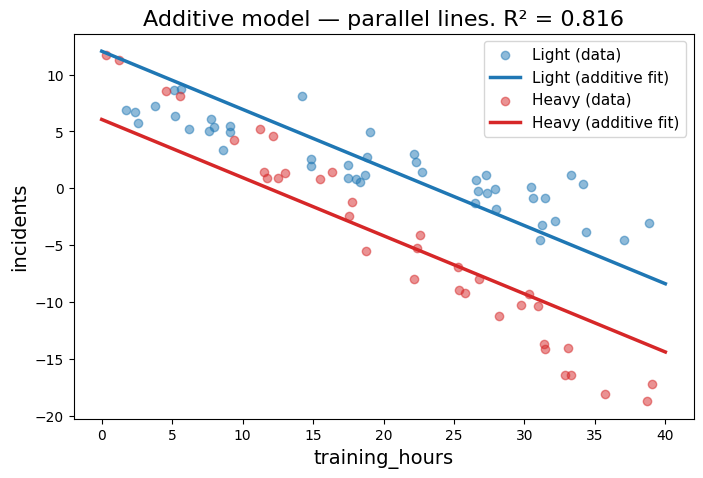

In [6]:
X_add = pd.DataFrame({
    'training_hours': df['training_hours'],
    'is_heavy': is_heavy,
})
X_add_c = sm.add_constant(X_add)
m_add = sm.OLS(df['incidents'], X_add_c).fit()
print(m_add.summary())

t_grid = np.linspace(0, 40, 100)
fig, ax = plt.subplots(figsize=(8, 5))
for mt, hv, color in [('Light', 0, 'tab:blue'), ('Heavy', 1, 'tab:red')]:
    mask = df['machine_type'] == mt
    ax.scatter(df.loc[mask, 'training_hours'], df.loc[mask, 'incidents'],
               label=f'{mt} (data)', alpha=0.5, color=color)
    y_hat = (m_add.params['const']
             + m_add.params['training_hours']*t_grid
             + m_add.params['is_heavy']*hv)
    ax.plot(t_grid, y_hat, color=color, linewidth=2.5, label=f'{mt} (additive fit)')
ax.set_xlabel('training_hours', fontsize=14)
ax.set_ylabel('incidents', fontsize=14)
ax.set_title(f'Additive model — parallel lines. R² = {m_add.rsquared:.3f}', fontsize=16)
ax.legend(fontsize=11)
plt.show()

<h2 dir="rtl">פרק 5 — מודל עם אינטראקציה</h2>

In [7]:
X_int = X_add.copy()
X_int['train_x_heavy'] = X_int['training_hours'] * X_int['is_heavy']
X_int_c = sm.add_constant(X_int)
m_int = sm.OLS(df['incidents'], X_int_c).fit()
print(m_int.summary())

                            OLS Regression Results                            
Dep. Variable:              incidents   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.953
Method:                 Least Squares   F-statistic:                     533.6
Date:                Sun, 17 May 2026   Prob (F-statistic):           5.99e-51
Time:                        01:00:11   Log-Likelihood:                -147.49
No. Observations:                  80   AIC:                             303.0
Df Residuals:                      76   BIC:                             312.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              7.8790      0.480     16.

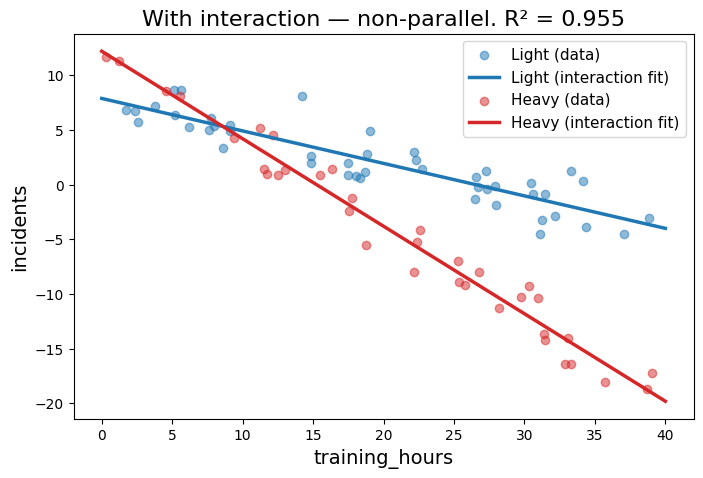

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
for mt, hv, color in [('Light', 0, 'tab:blue'), ('Heavy', 1, 'tab:red')]:
    mask = df['machine_type'] == mt
    ax.scatter(df.loc[mask, 'training_hours'], df.loc[mask, 'incidents'],
               label=f'{mt} (data)', alpha=0.5, color=color)
    y_hat = (m_int.params['const']
             + m_int.params['training_hours']*t_grid
             + m_int.params['is_heavy']*hv
             + m_int.params['train_x_heavy']*t_grid*hv)
    ax.plot(t_grid, y_hat, color=color, linewidth=2.5, label=f'{mt} (interaction fit)')
ax.set_xlabel('training_hours', fontsize=14)
ax.set_ylabel('incidents', fontsize=14)
ax.set_title(f'With interaction — non-parallel. R² = {m_int.rsquared:.3f}', fontsize=16)
ax.legend(fontsize=11)
plt.show()

<h2 dir="rtl">פרק 6 — פירוש $\beta_3$ — שני שיפועים</h2>

In [9]:
b0 = m_int.params['const']
b1 = m_int.params['training_hours']
b2 = m_int.params['is_heavy']
b3 = m_int.params['train_x_heavy']

light_intercept = b0
light_slope = b1
heavy_intercept = b0 + b2
heavy_slope = b1 + b3

print(f'Light machines: incidents = {light_intercept:.3f} + ({light_slope:+.3f}) * training_hours')
print(f'Heavy machines: incidents = {heavy_intercept:.3f} + ({heavy_slope:+.3f}) * training_hours')
print()
print(f'Slope difference (b3 = heavy_slope - light_slope) = {b3:+.3f}')

Light machines: incidents = 7.879 + (-0.297) * training_hours
Heavy machines: incidents = 12.196 + (-0.800) * training_hours

Slope difference (b3 = heavy_slope - light_slope) = -0.503


In [10]:
# הרחבה: continuous x continuous — אותה מכניקה, X2 רציף
rng_cc = np.random.default_rng(7)
n_cc = 60
training_cc = rng_cc.uniform(0, 40, size=n_cc)
age_cc = rng_cc.uniform(0, 20, size=n_cc)
y_true_cc = 5 - 0.2*training_cc + 0.4*age_cc - 0.02*(training_cc*age_cc)
incidents_cc = y_true_cc + rng_cc.normal(0, 1.0, size=n_cc)

X_cc = pd.DataFrame({
    'training': training_cc,
    'machine_age': age_cc,
    'train_x_age': training_cc * age_cc,
})
m_cc = sm.OLS(incidents_cc, sm.add_constant(X_cc)).fit()
print(m_cc.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.966
Model:                            OLS   Adj. R-squared:                  0.964
Method:                 Least Squares   F-statistic:                     535.3
Date:                Sun, 17 May 2026   Prob (F-statistic):           3.53e-41
Time:                        01:00:11   Log-Likelihood:                -77.156
No. Observations:                  60   AIC:                             162.3
Df Residuals:                      56   BIC:                             170.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           5.1992      0.455     11.420      

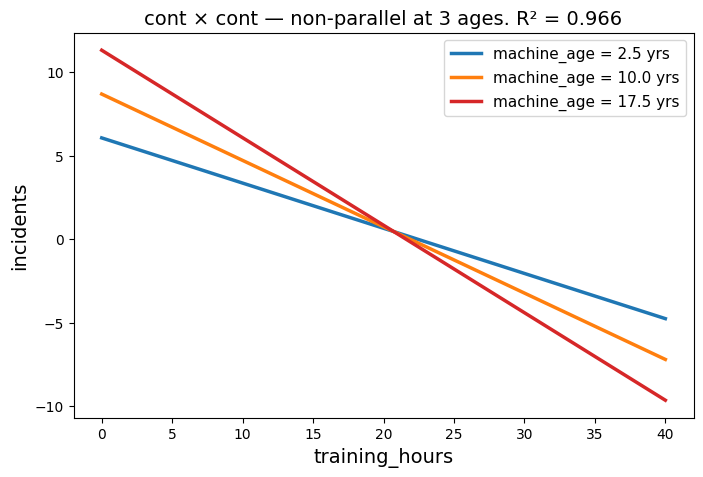

In [11]:
t_grid_cc = np.linspace(0, 40, 100)
fig, ax = plt.subplots(figsize=(8, 5))
for a_level, color in [(2.5, 'tab:blue'), (10.0, 'tab:orange'), (17.5, 'tab:red')]:
    y_hat = (m_cc.params['const']
             + m_cc.params['training']*t_grid_cc
             + m_cc.params['machine_age']*a_level
             + m_cc.params['train_x_age']*t_grid_cc*a_level)
    ax.plot(t_grid_cc, y_hat, color=color, linewidth=2.5, label=f'machine_age = {a_level} yrs')
ax.set_xlabel('training_hours', fontsize=14)
ax.set_ylabel('incidents', fontsize=14)
ax.set_title(f'cont × cont — non-parallel at 3 ages. R² = {m_cc.rsquared:.3f}', fontsize=14)
ax.legend(fontsize=11)
plt.show()

<h2 dir="rtl">פרק 7 — F-test ועקרון ההיררכיה</h2>

In [12]:
f_stat, p_val, df_diff = m_int.compare_f_test(m_add)
print(f'F-test (additive vs with-interaction):')
print(f'  F = {f_stat:.4f}')
print(f'  p = {p_val:.4g}')
print(f'  df_diff = {df_diff} (one term added)')

F-test (additive vs with-interaction):
  F = 233.2640
  p = 7.21e-25
  df_diff = 1.0 (one term added)


<h2 dir="rtl">פרק 8 — סיכום בלוק לינארי + גשר ללוגיסטית</h2>

### Write your answer here.

<div dir="rtl">

יש לך מודל לחיזוי תקלות לפי שעות הכשרה. הצענו לך שני מודלים:

- **(א)** $\hat Y = b_0 + b_1 \cdot \text{training} + b_2 \cdot \text{machine\_heavy}$ (אדיטיבי).
- **(ב)** אותו דבר $+ b_3 \cdot \text{training} \cdot \text{machine\_heavy}$ (אינטראקציה).

בלי להריץ קוד — איזה משפט עליהם נכון?

1. ב-(א), השיפוע של training הוא $-0.5$ אז זה גם השיפוע של Heavy.
2. ב-(ב), השיפוע של Heavy שווה ל-$b_1 + b_3$ ולא לסכום $b_1 + b_2 + b_3$.
3. ב-(ב), אם נמרכז את training, $b_3$ יעלם.
4. F-test בין (א) ל-(ב) ייתן $df = 2$.

</div>